# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet
import os
import sys
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.config import PERIOD_START, PERIOD_END, select_period
from src.gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    learn_gap_dist,
    create_artificial_gap_splits,
    plot_cv_splits
)

# CONFIGURATION

In [2]:
START_DATE, END_DATE = PERIOD_START, PERIOD_END  # dataset period, see src/config.py
TARGET_FLUX = 'FCH4'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = True # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_TRT = True

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"83.1.1_GapFillingDataset.parquet")
data_main = select_period(data_main, timestamp='middle')
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 83.1.1_GapFillingDataset.parquet (0.824 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
select_period: kept 14928 of 14928 records (2023-10-17 00:15:00 to 2024-08-22 23:45:00, timestamp=middle)

Using data from 2023-10-17 00:00:00 to 2024-08-23 00:00:00

Target column: FCH4_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,FCH4_L3.3_CUT_16_QCF,FCH4_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_84_QCF,FCH4_L3.3_CUT_16_QCF0,FCH4_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FCH4_RANDUNC_HF,SW_IN_POT,prec,ta,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 00:15:00,5.957099,-4.642565,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.966667,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,NaN,0
2023-10-17 00:45:00,5.957099,-4.642565,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.966667,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,NaN,1
2023-10-17 01:15:00,5.957099,-4.676087,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.566667,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,NaN,2
2023-10-17 01:45:00,5.957099,-4.701027,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.266667,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,NaN,3
2023-10-17 02:15:00,5.957099,-4.689964,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.400000,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,5.789159,-1.174224,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,10.56010,0.0,0.0,15.870000,...,-1.456268,-0.031887,-0.371716,-0.464268,184.456349,187.286349,174.585550,12.443672,188.0,1.0,30.0,1.0,0.0,0.0,14923
2024-08-22 22:15:00,5.719062,-1.229992,49.8381,49.8381,NaN,NaN,NaN,NaN,B,certain,1.0,8.79062,0.0,0.0,15.160000,...,-1.399429,-0.000719,-0.361714,-0.454507,184.269841,187.279204,173.906660,14.317380,188.0,1.0,30.0,1.0,0.0,0.0,14924
2024-08-22 22:45:00,5.507258,-1.028798,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,10.10600,0.0,0.0,15.100000,...,-1.435013,0.009201,-0.350463,-0.453738,184.083333,187.271988,173.230410,16.309472,188.0,1.0,30.0,1.0,0.0,0.0,14925


# CLEAN DATA

In [4]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

data

Filtered parcel_certainty=='certain': 1357/1552 rows kept


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,FCH4_L3.3_CUT_16_QCF,FCH4_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_84_QCF,FCH4_L3.3_CUT_16_QCF0,FCH4_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FCH4_RANDUNC_HF,SW_IN_POT,prec,ta,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 17:15:00,2.060704,-0.782134,2.488800,2.488800,2.488800,2.488800,2.488800,2.488800,B,certain,1.0,2.231300,3.38364,0.5,6.600000,...,0.029544,0.798931,0.793294,0.894488,0.0,0.0,2.263177,1.031258,29.0,22.0,30.0,22.0,0.087050,0.189415,1042
2023-11-07 17:45:00,1.999698,-0.715234,-9.177059,-9.177059,-9.177059,-9.177059,-9.177059,-9.177059,B,certain,1.0,3.268680,0.00000,0.2,6.633333,...,0.435220,0.764205,0.910265,0.877980,0.0,0.0,2.257514,1.027996,29.0,22.0,30.0,22.0,0.087144,0.189803,1043
2023-11-07 18:45:00,1.949714,-0.687676,0.731597,0.731597,0.731597,0.731597,0.731597,0.731597,B,certain,1.0,0.844661,0.00000,0.0,6.200000,...,0.383403,0.812505,0.958576,1.030199,0.0,0.0,2.246230,1.021509,29.0,22.0,30.0,22.0,0.087331,0.190579,1045
2023-11-07 21:45:00,1.738101,-0.473284,0.839584,0.839584,0.839584,0.839584,0.839584,0.839584,B,certain,1.0,2.199510,0.00000,0.0,5.933333,...,0.174533,1.298679,1.684642,1.563690,0.0,0.0,2.212716,1.002328,29.0,22.0,30.0,22.0,0.087891,0.192918,1051
2023-11-07 23:45:00,1.722952,-0.483582,-16.076329,-16.076329,-16.076329,-16.076329,-16.076329,-16.076329,B,certain,1.0,4.050600,0.00000,0.0,5.366667,...,0.612817,-0.715041,0.049164,0.548832,0.0,0.0,2.190652,0.989773,29.0,22.0,30.0,22.0,0.088265,0.194485,1055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-20 08:15:00,1.855749,2.847566,-19.752590,-19.752590,-19.752590,-19.752590,-19.752590,-19.752590,A,certain,0.0,7.240710,654.93300,0.0,16.366667,...,-2.097743,-0.031954,0.008492,0.263486,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14800
2024-08-20 13:45:00,1.879419,3.660084,-6.165051,-6.165051,-6.165051,-6.165051,-6.165051,-6.165051,A,certain,0.0,2.571020,1030.14000,0.0,21.006667,...,-1.721083,-0.117190,-0.138414,0.034627,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14811
2024-08-21 00:15:00,4.887125,0.455124,45.188613,45.188613,45.188613,45.188613,45.188613,45.188613,B,certain,1.0,11.798600,0.00000,0.0,19.920000,...,-1.507235,0.153967,-0.062227,-0.147486,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14832


# SELECT FEATURES

In [5]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')

# Drop NAs and keep only selected features
train_mask = data[TARGET].notna() & data[selected_features].notna().all(axis=1)
df_train = data.loc[train_mask, selected_features + [TARGET]].copy()
print(f"\nTraining rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[selected_features]
y = df_train[TARGET].astype(float)

df_train


The treatment variable (trt) is included in the feature set

Training rows (complete-case): 1357/1357


,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,trt,prec,timesince_soil_preparation,ta_lag3h,ts_0.15_gfXG_lag9h,ts_0.3_gfXG_lag9h,wfps_0.3_gfXG_lag3h,wfps_0.3_gfXG_lag6h,ta_roll3hmean,ta_roll6hmean,ts_0.05_gfXG_roll3hmean,ts_0.05_gfXG_roll6hmean,ts_0.05_gfXG_roll9hmean,ts_0.15_gfXG_roll6hmean,...,wfps_0.3_gfXG_lag9h_roll6hmean,wfps_0.3_gfXG_lag9h_roll9hmean,ts_0.05_gfXG_diff6h,ts_0.05_gfXG_diff12h,ts_0.15_gfXG_diff6h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.15_gfXG_diff12h,n_decay_linear,n_decay_timed,timesince_fert,id,FCH4_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 17:15:00,-0.782134,1.0,0.5,21.0,9.500000,3.993344,4.716949,43.395454,43.312703,7.516667,8.666667,6.420618,6.817826,6.183196,5.174855,...,43.079525,43.064787,-0.332288,1.345672,2.433305,-0.094835,-1.131584,0.295964,-0.018966,-0.081217,0.0,29.0,22.0,1042,2.488800
2023-11-07 17:45:00,-0.715234,1.0,0.2,21.0,8.733333,4.106302,4.615815,43.413050,43.362600,7.166667,8.413889,6.131985,6.711119,6.247142,5.384375,...,43.081573,43.078897,-1.280482,1.243580,2.514249,-0.011838,-1.140057,0.386403,0.231753,0.200712,0.0,29.0,22.0,1043,-9.177059
2023-11-07 18:45:00,-0.687676,1.0,0.0,21.0,7.366667,3.914358,4.279192,43.478006,43.360996,6.711111,7.791667,5.469745,6.341008,6.279377,5.699896,...,43.140772,43.092170,-2.587183,-0.483406,1.749761,-0.085806,-1.116406,-0.599095,-0.724384,0.140143,0.0,29.0,22.0,1045,0.731597
2023-11-07 21:45:00,-0.473284,1.0,0.0,21.0,6.200000,4.428715,4.011118,44.173501,43.478006,6.100000,6.405556,4.316874,4.893310,5.666296,5.940038,...,43.203116,43.193437,-2.599371,-0.622377,-0.339902,-0.700626,-0.820170,0.243140,0.420500,-0.167952,0.0,29.0,22.0,1051,0.839584
2023-11-07 23:45:00,-0.483582,1.0,0.0,21.0,6.233333,5.605748,3.987010,44.303959,44.126805,5.694444,5.944444,3.859618,4.239560,4.870368,5.606333,...,43.296548,43.244264,-1.931181,-3.211663,-1.260064,-1.057067,-1.100695,-0.083510,0.302893,-0.286814,0.0,29.0,22.0,1055,-16.076329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-20 08:15:00,2.847566,0.0,0.0,15.0,15.466667,21.200000,20.599259,43.043614,43.053516,15.806111,15.721667,19.198086,19.258580,19.407391,20.397901,...,43.011280,42.981996,-0.102222,-1.627779,-0.630740,0.242223,-0.154816,-0.160069,-0.595461,-0.714479,0.0,0.0,30.0,14800,-19.752590
2024-08-20 13:45:00,3.660084,0.0,0.0,16.0,17.500000,20.464074,20.237035,42.986526,43.031115,19.426667,18.177222,21.318580,20.563456,20.091543,20.336235,...,43.050980,43.046342,3.488148,3.175924,0.560370,-0.536296,-0.231113,-0.298063,-0.486618,-0.740482,0.0,0.0,30.0,14811,-6.165051
2024-08-21 00:15:00,0.455124,1.0,0.0,16.0,18.660000,21.317407,20.042592,42.883436,42.750976,19.493333,19.805833,20.979135,21.807222,22.736172,21.960741,...,42.945574,42.972351,-3.348517,-0.430369,-0.817778,0.436666,0.134520,-0.742244,-2.381714,-0.733296,0.0,0.0,30.0,14832,45.188613


# IMBALANCE HANDLING

## UNDER SAMPLING

In [6]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.8,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

In [7]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")

Log transform not applied.


# CROSS-VAL SPLITS

  Gap distribution: raw empirical (cvm distance 7.5497; raw baseline 7.5497)
CV Strategy: artificial gaps in real time; 10 splits; test fractions 0.097-0.106
  Coverage: 461/1357 rows never held out (34.0%); mean times held out 1.02


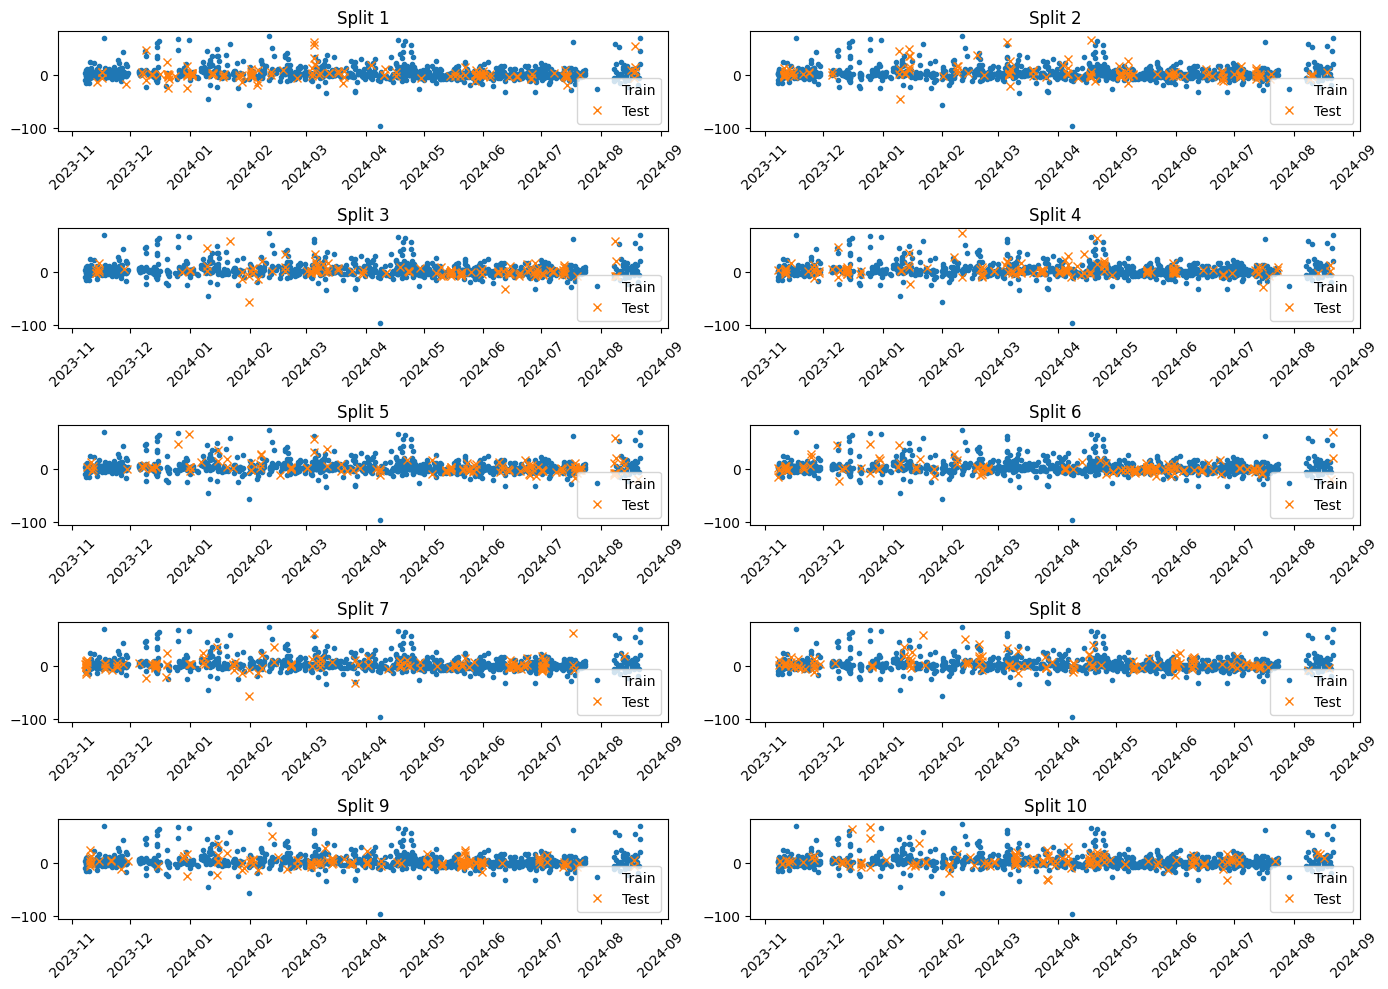

In [8]:
# Artificial-gap CV splits (Irvin et al. 2021 style)
rng = np.random.default_rng(42)

sampling_pmf = learn_gap_dist(data_main[TARGET], n_grid=6, n_mc=20, rng=rng, verbose=True)

splits, coverage = create_artificial_gap_splits(
    target_full=data_main[TARGET],   # full series, real NaNs intact -- NOT X/y
    train_index=X.index,
    sampling_pmf=sampling_pmf,
    n_splits=N_FOLDS,
    eval_frac=0.1,
    rng=rng,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# HYPERPARAMETER TUNING

In [9]:
# DEFINE RANGES
if MODEL_TYPE == 'XGBoost':
    # XGBoost: Use continuous distributions for fine-tuning
    PARAM_DIST = {
        'n_estimators': randint(100, 1000),      # Any integer 100-1000
        'max_depth': randint(3, 15),             # Any integer 3-15
        'learning_rate': uniform(0.005, 0.1),    # Any float 0.005-0.105
        'subsample': uniform(0.6, 0.4),          # 0.6 to 1.0
        'colsample_bytree': uniform(0.6, 0.4),   # 0.6 to 1.0
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0, 0.5)
    }
    model = XGBRegressor(n_jobs=-1, random_state=42)

elif MODEL_TYPE == 'RandomForest':
    # RF: Integers for counts/depths
    PARAM_DIST = {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', 1.0]
    }
    model = RandomForestRegressor(n_jobs=-1, random_state=42)

# RUN RANDOM SEARCH
print(f"Starting optimization for {MODEL_TYPE}...")

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=PARAM_DIST,
    n_iter=100,      # number of random tries
    cv=splits,       # list of (train_idx, test_idx) 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X, y)

# RESULTS
print(f"Best RMSE: {-search.best_score_:.4f}")
print("Best Params:", search.best_params_)

Starting optimization for XGBoost...
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best RMSE: 11.7290
Best Params: {'colsample_bytree': np.float64(0.8887995089067299), 'gamma': np.float64(0.4692763545078751), 'learning_rate': np.float64(0.005077876584101433), 'max_depth': 14, 'min_child_weight': 5, 'n_estimators': 260, 'subsample': np.float64(0.7216968971838151)}


# EXPORT 

In [10]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(search.best_params_, f)

# **End of notebook**

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-09-23 19:38:11
